In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

# dot-bracket and sequence -> colored bpgrid (based on AU or GC bp)

In [18]:
df_subset_numpeaks1or2 = pd.read_parquet('dataset_with_fpts_subset_numpeaks1or2.parquet')
df = df_subset_numpeaks1or2

In [19]:
def has_other_letters(s):
    valid_chars = set('AUCG')
    return any(char not in valid_chars for char in s)

counter = 0
for row in df.itertuples():
    if has_other_letters(row.sequence):
        #print(row.Index, row.sequence)
        counter += 1
print(counter)

640


In [20]:
mask_rows = df['sequence'].apply(lambda seq: not has_other_letters(seq))
df_subset = df[mask_rows]
print(len(df_subset))

7581


In [21]:
df_subset_numpeaks1or2 = df_subset

In [22]:
row_stride = 500
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index, row.mfe_structure)

0 ...............
500 ....................
1000 (.((((......)))).)....
1500 ........................
2000 ((((((............))))))..
2500 .........((((.((....)).)))).
3000 ...........((.((((....)))).)).
3500 ..(((((....((......))...)))))...
4000 ((((((((((((((((((...(((....))))))))).))....))))))))))..
4500 ....((((((.....((((......))))...)))))).........................
5000 (((((((((((..........(((((((((............)))).)))))))))..))))))).
5500 .(((((((((((......))))........))))))).((((...((((......))))...))))...
6000 .(((((...(((((.....))))).((((......((.(((((...))))).))....))))...))))).
6500 (((((((.((.(...(((((((((((.....)).)))))))))..((((.(.....).))))).))))))))).
7000 .((.((((.(((((((((((...)))).))).)))).))))..)).(.(((..((((((....)))).))..))).).
7500 ((((((...(((.....(((((((((......(((((((((....))).))))))(((....)))))))))))))))...))))))
8000 ((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....


In [23]:
def get_bp_value(nuc1, nuc2):
    if (nuc1 == 'A' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'A'):
        return 1
    if (nuc1 == 'G' and nuc2 == 'C') or (nuc1 == 'C' and nuc2 == 'G'):
        return 2
    if (nuc1 == 'G' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'G'):
        return 3
    else:
        raise ValueError(f"Nucleotides {nuc1} and {nuc2} do not form a valid base pair")

def dotbrack_seq_to_colored_matrix(dot_bracket_string, seq_string):    
    n = len(dot_bracket_string)
    if len(seq_string) != n:
        raise ValueError("dot_bracket_string and seq_string must be the same length")
    # 1. Initialize an N x N matrix with zeros
    matrix = [[0 for _ in range(n)] for _ in range(n)]
    stack = []
    nuc_stack = []
    
    # 2. Loop through the string
    for i, char in enumerate(dot_bracket_string):
        nuc = seq_string[i] # nucleotide
        if char == '(':
            stack.append(i) # Save the index of the open bracket
            nuc_stack.append(nuc) # save the first nucleotide of the base pair
        elif char == ')':
            if stack:
                j = stack.pop() # Retrieve the matching open bracket index
                nuc1 = nuc_stack.pop() # retrieve the first nucleotide of the base pair
                
                bp_value = get_bp_value(nuc1, nuc)

                # 3. Mark the base pair (convert from 0-based to 1-based index if desired)
                matrix[i][j] = bp_value
                matrix[j][i] = bp_value
                
    return matrix

..(((((....((......))...)))))...
UCCGGGCCAAUUCCAAGCAGACCUGCCUGAAA
32


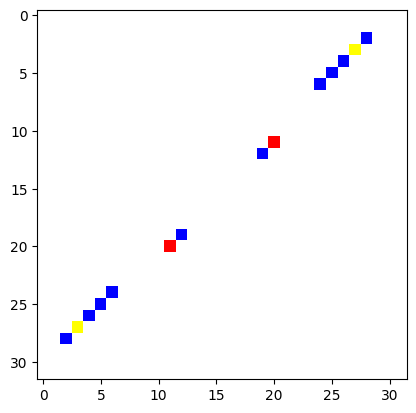

In [24]:
dotbracket = df_subset_numpeaks1or2.loc[3500, 'mfe_structure']
seq = df_subset_numpeaks1or2.loc[3500, 'sequence']
print(dotbracket)
print(seq)
print(len(dotbracket))
bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)
plt.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)

((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....
AGCUGGUCCAAUGGUAAUGGGUUAUCAGAACUUAUUAACACCAGUGUCACUAAAGUUGAUGUACAGUCCCCCCACUGCUAAAUUUGACUGGCUUAAA
97


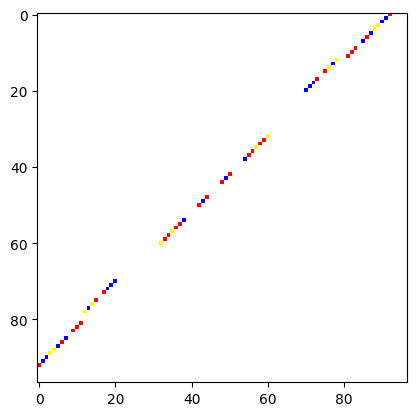

In [25]:
dotbracket = df_subset_numpeaks1or2.loc[8000, 'mfe_structure']
seq = df_subset_numpeaks1or2.loc[8000, 'sequence']
print(dotbracket)
print(seq)
print(len(dotbracket))
bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)
plt.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)

379


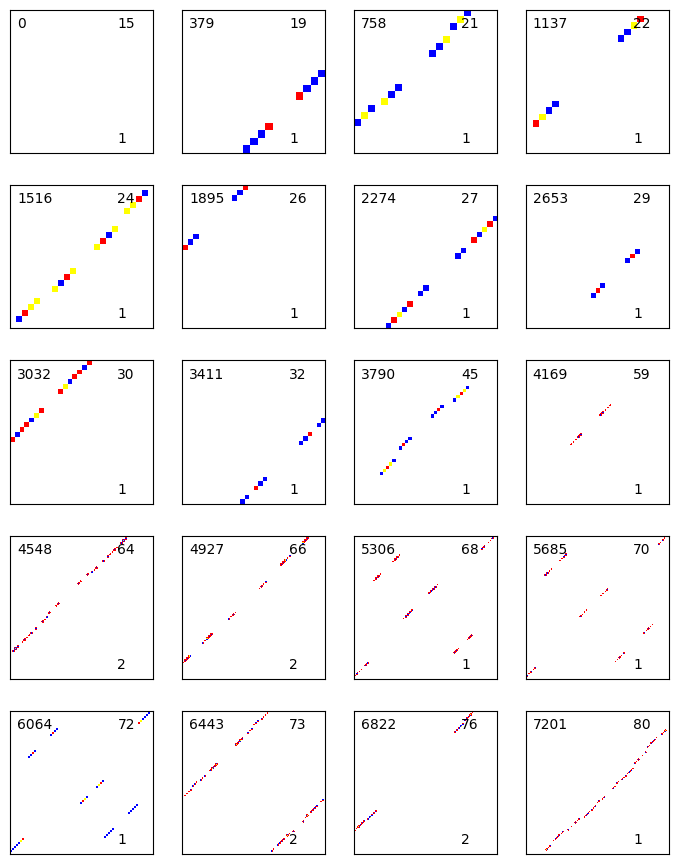

In [26]:
width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

row_stride = int(len(df_subset_numpeaks1or2)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored.pdf', bbox_inches='tight', pad_inches=0.25)

277


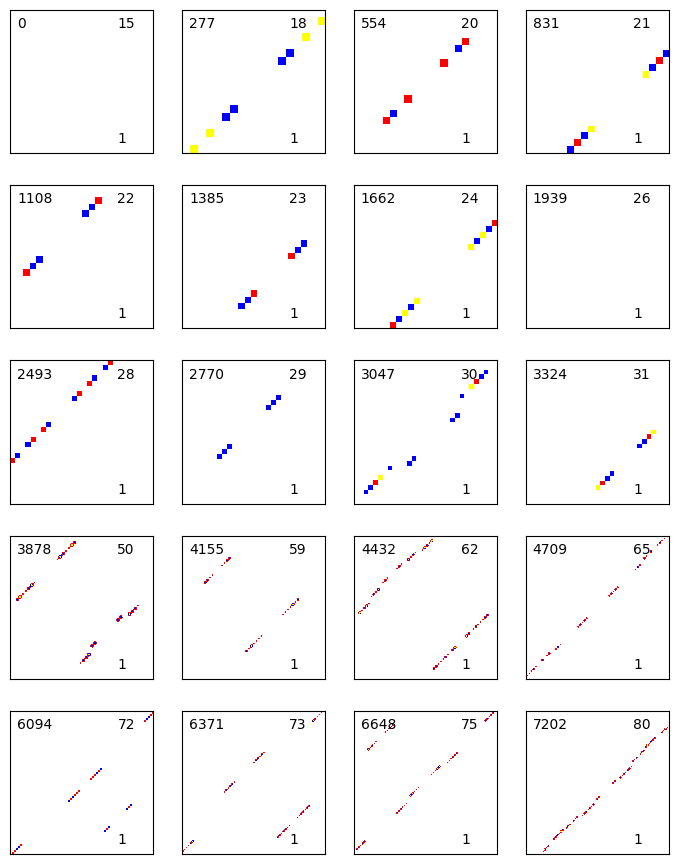

In [27]:
# 1 peak

width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==1]
row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored_1peak.pdf', bbox_inches='tight', pad_inches=0.25)

101


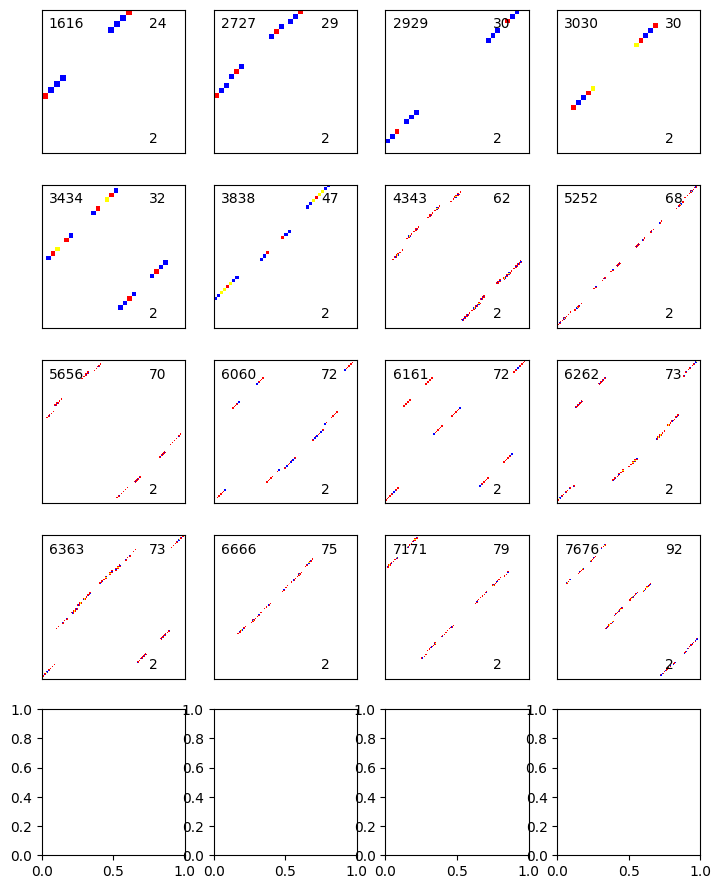

In [28]:
# 2 peaks

width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==2]
row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored_2peaks.pdf', bbox_inches='tight', pad_inches=0.25)

# sequence -> self-complementarity

In [29]:
df_subset_numpeaks1or2 = pd.read_parquet('dataset_with_fpts_subset_numpeaks1or2.parquet')
df = df_subset_numpeaks1or2

In [30]:
def has_other_letters(s):
    valid_chars = set('AUCG')
    return any(char not in valid_chars for char in s)

counter = 0
for row in df.itertuples():
    if has_other_letters(row.sequence):
        #print(row.Index, row.sequence)
        counter += 1
print(counter)

640


In [31]:
mask_rows = df['sequence'].apply(lambda seq: not has_other_letters(seq))
df_subset = df[mask_rows]
print(len(df_subset))

7581


In [32]:
df_subset_numpeaks1or2 = df_subset

In [33]:
row_stride = 500
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index, row.mfe_structure)

0 ...............
500 ....................
1000 (.((((......)))).)....
1500 ........................
2000 ((((((............))))))..
2500 .........((((.((....)).)))).
3000 ...........((.((((....)))).)).
3500 ..(((((....((......))...)))))...
4000 ((((((((((((((((((...(((....))))))))).))....))))))))))..
4500 ....((((((.....((((......))))...)))))).........................
5000 (((((((((((..........(((((((((............)))).)))))))))..))))))).
5500 .(((((((((((......))))........))))))).((((...((((......))))...))))...
6000 .(((((...(((((.....))))).((((......((.(((((...))))).))....))))...))))).
6500 (((((((.((.(...(((((((((((.....)).)))))))))..((((.(.....).))))).))))))))).
7000 .((.((((.(((((((((((...)))).))).)))).))))..)).(.(((..((((((....)))).))..))).).
7500 ((((((...(((.....(((((((((......(((((((((....))).))))))(((....)))))))))))))))...))))))
8000 ((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....


In [34]:
def bp_score(a, b):
    pairs = {('A','U'):1, ('U','A'):1,
             ('G','C'):1, ('C','G'):1,
             ('G','U'):0.5, ('U','G'):0.5}  # wobble weighted lower
    return pairs.get((a,b), -1)  # mismatch penalty

def self_complementarity_matrix(seq, min_loop=3, gap_penalty=-1):
    n = len(seq)
    rev = seq[::-1]
    H = np.zeros((n+1, n+1))
    
    for i in range(1, n+1):
        for j in range(1, n+1):
            # i indexes seq (1-based), j indexes rev (1-based)
            # position in original seq for rev[j-1] is n-j
            orig_j = n - j  # 0-based index in seq
            score = bp_score(seq[i-1], seq[orig_j])
            diag = H[i-1, j-1] + score
            H[i, j] = max(0, diag)  # local alignment: reset at 0
    return H, rev

UCCGGGCCAAUUCCAAGCAGACCUGCCUGAAA
32


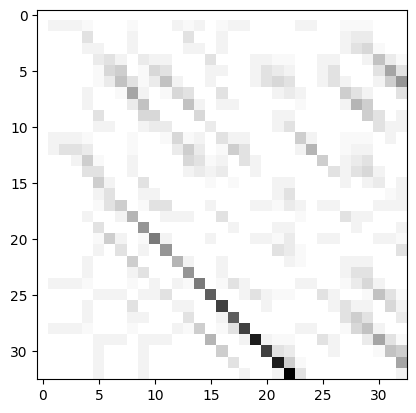

In [35]:
seq = df_subset_numpeaks1or2.loc[3500, 'sequence']
print(seq)
print(len(seq))
H, rev = self_complementarity_matrix(seq)
plt.imshow(H, cmap='Grays')

AGCUGGUCCAAUGGUAAUGGGUUAUCAGAACUUAUUAACACCAGUGUCACUAAAGUUGAUGUACAGUCCCCCCACUGCUAAAUUUGACUGGCUUAAA
97


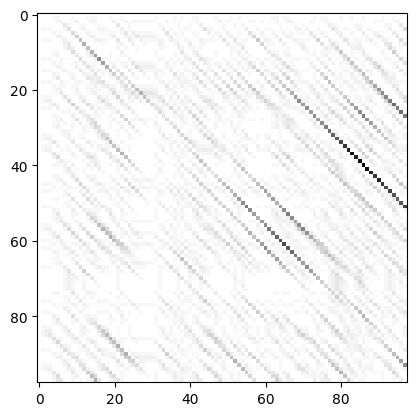

In [36]:
seq = df_subset_numpeaks1or2.loc[8000, 'sequence']
print(seq)
print(len(seq))
H, rev = self_complementarity_matrix(seq)
plt.imshow(H, cmap='Grays')

In [37]:
def kmer_comp_map(seq, k=6):
    n = len(seq)
    comp = str.maketrans('AUGC', 'UACG')
    scores = np.zeros((n, n))
    for i in range(n - k):
        kmer = seq[i:i+k]
        target = kmer.translate(comp)[::-1]  # reverse complement
        for j in range(n - k):
            if j > i:  # avoid re-checking symmetric pairs twice, and trivial adjacency
                match = sum(a == b for a, b in zip(seq[j:j+k], target))
                scores[i, j] = match / k
    return scores

UCCGGGCCAAUUCCAAGCAGACCUGCCUGAAA
32
2


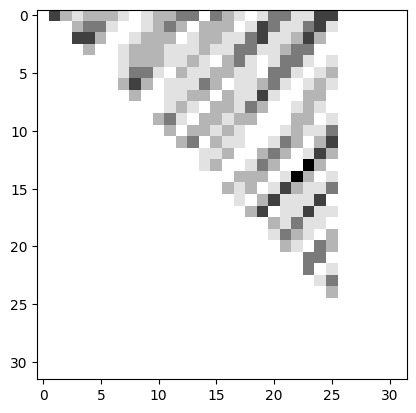

In [38]:
seq = df_subset_numpeaks1or2.loc[3500, 'sequence']
print(seq)
print(len(seq))
print(df_subset_numpeaks1or2.loc[3500, 'num_peaks'])
scores = kmer_comp_map(seq)
plt.imshow(scores, cmap='Grays')

AGCUGGUCCAAUGGUAAUGGGUUAUCAGAACUUAUUAACACCAGUGUCACUAAAGUUGAUGUACAGUCCCCCCACUGCUAAAUUUGACUGGCUUAAA
97
1


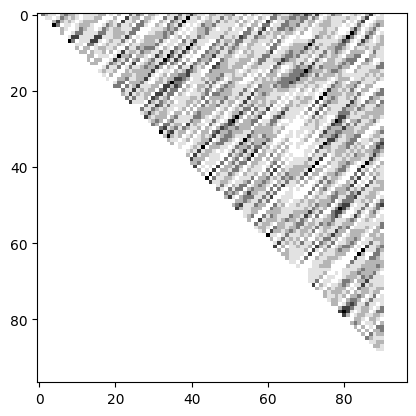

In [39]:
seq = df_subset_numpeaks1or2.loc[8000, 'sequence']
print(seq)
print(len(seq))
print(df_subset_numpeaks1or2.loc[8000, 'num_peaks'])
scores = kmer_comp_map(seq)
plt.imshow(scores, cmap='Grays')

1263


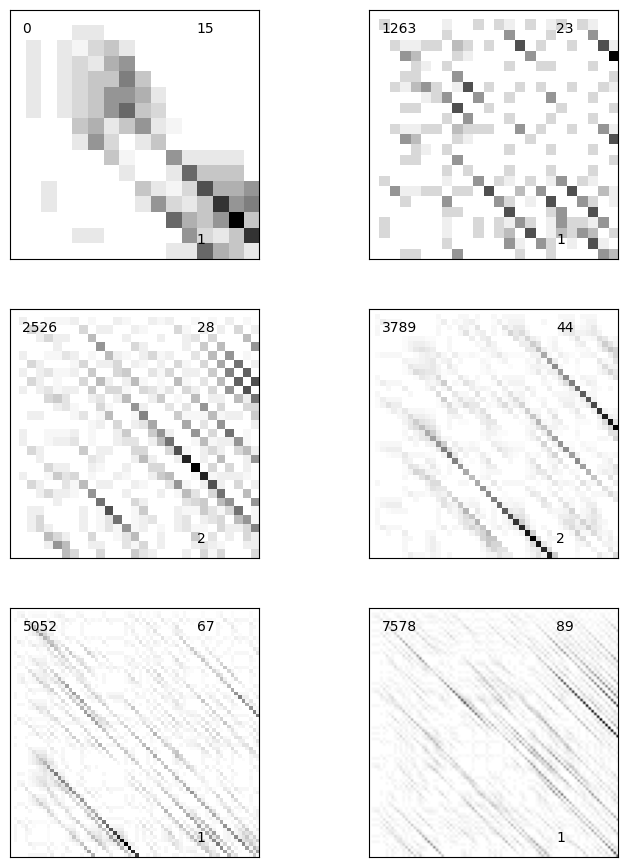

In [40]:
width_inch = 8.5
height_inch = 11
n_x = 2
n_y = 3
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

df_here = df_subset_numpeaks1or2

row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        seq = row.sequence
        H, rev = self_complementarity_matrix(seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(H, cmap='Grays')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('self_comp.pdf', bbox_inches='tight', pad_inches=0.25)

924


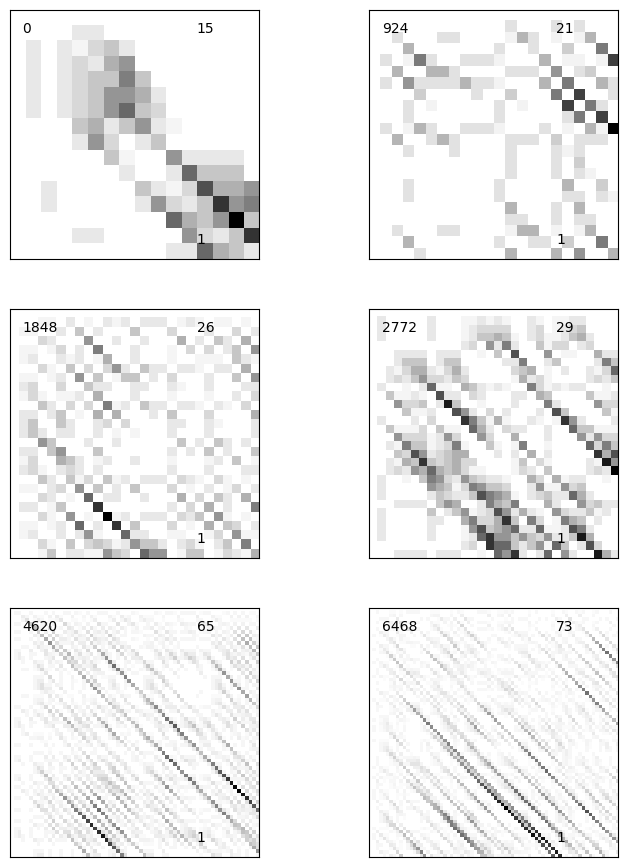

In [41]:
# 1 peak

width_inch = 8.5
height_inch = 11
n_x = 2
n_y = 3
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==1]

row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        seq = row.sequence
        H, rev = self_complementarity_matrix(seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(H, cmap='Grays')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('self_comp_1peak.pdf', bbox_inches='tight', pad_inches=0.25)

339


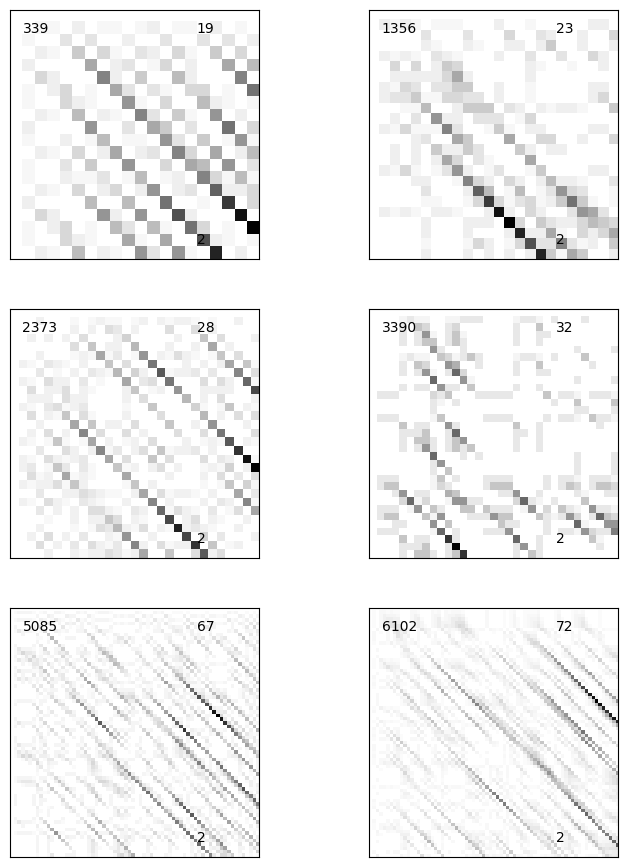

In [42]:
# 2 peaks

width_inch = 8.5
height_inch = 11
n_x = 2
n_y = 3
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==2]

row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        seq = row.sequence
        H, rev = self_complementarity_matrix(seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(H, cmap='Grays')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('self_comp_2peaks.pdf', bbox_inches='tight', pad_inches=0.25)

# suboptimal structures

In [43]:
import RNA

In [45]:
df_subset_numpeaks1or2 = pd.read_parquet('dataset_with_fpts_subset_numpeaks1or2.parquet')
df = df_subset_numpeaks1or2

In [46]:
def has_other_letters(s):
    valid_chars = set('AUCG')
    return any(char not in valid_chars for char in s)

counter = 0
for row in df.itertuples():
    if has_other_letters(row.sequence):
        #print(row.Index, row.sequence)
        counter += 1
print(counter)

640


In [47]:
mask_rows = df['sequence'].apply(lambda seq: not has_other_letters(seq))
df_subset = df[mask_rows]
print(len(df_subset))

7581


In [48]:
df_subset_numpeaks1or2 = df_subset

In [49]:
row_stride = 500
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index, row.mfe_structure)

0 ...............
500 ....................
1000 (.((((......)))).)....
1500 ........................
2000 ((((((............))))))..
2500 .........((((.((....)).)))).
3000 ...........((.((((....)))).)).
3500 ..(((((....((......))...)))))...
4000 ((((((((((((((((((...(((....))))))))).))....))))))))))..
4500 ....((((((.....((((......))))...)))))).........................
5000 (((((((((((..........(((((((((............)))).)))))))))..))))))).
5500 .(((((((((((......))))........))))))).((((...((((......))))...))))...
6000 .(((((...(((((.....))))).((((......((.(((((...))))).))....))))...))))).
6500 (((((((.((.(...(((((((((((.....)).)))))))))..((((.(.....).))))).))))))))).
7000 .((.((((.(((((((((((...)))).))).)))).))))..)).(.(((..((((((....)))).))..))).).
7500 ((((((...(((.....(((((((((......(((((((((....))).))))))(((....)))))))))))))))...))))))
8000 ((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....


In [68]:
def get_subopt_hist(seq):
    energy_window_kcal = 5
    RT = 0.61597  # kcal/mol at 37 C
    n_bins = 1000

    fc = RNA.fold_compound(seq)
    mfe_struct, mfe = fc.mfe()
    subopt = fc.subopt(int(round(energy_window_kcal * 100)))
    structs = sorted(set((s.structure, s.energy) for s in subopt),
                        key=lambda x: x[1])

    dists = np.array([RNA.bp_distance(mfe_struct, s) for s, _ in structs], dtype=float)
    energies = np.array([e for _, e in structs])
    gaps = energies - mfe
    weights = np.exp(-gaps / RT)
    weights /= weights.sum()

    dmax = max(dists.max(), 1.0)
    bin_edges = np.linspace(0, dmax + 1e-6, n_bins + 1)
    bin_idx = np.clip(np.digitize(dists, bin_edges) - 1, 0, n_bins - 1)
    hist = np.zeros(n_bins)
    for b, w in zip(bin_idx, weights):
        hist[b] += w
    
    return hist, bin_edges

UCCGGGCCAAUUCCAAGCAGACCUGCCUGAAA
32


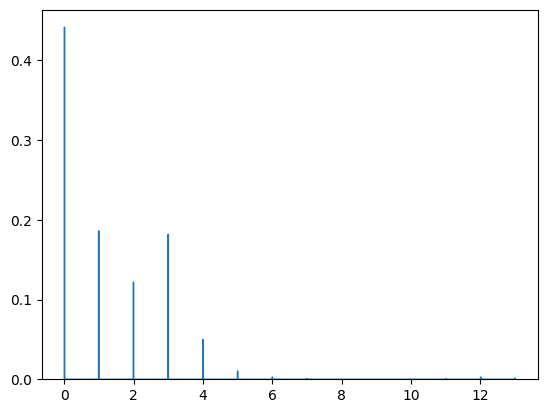

In [69]:
seq = df_subset_numpeaks1or2.loc[3500, 'sequence']
print(seq)
print(len(seq))
hist, bin_edges = get_subopt_hist(seq)
plt.stairs(hist, bin_edges)

AGCUGGUCCAAUGGUAAUGGGUUAUCAGAACUUAUUAACACCAGUGUCACUAAAGUUGAUGUACAGUCCCCCCACUGCUAAAUUUGACUGGCUUAAA
97


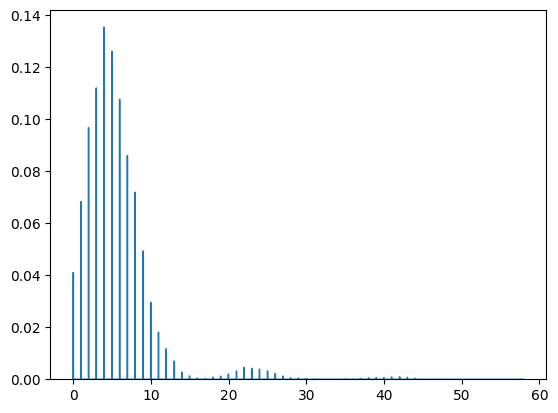

In [70]:
seq = df_subset_numpeaks1or2.loc[8000, 'sequence']
print(seq)
print(len(seq))
hist, bin_edges = get_subopt_hist(seq)
plt.stairs(hist, bin_edges)

126


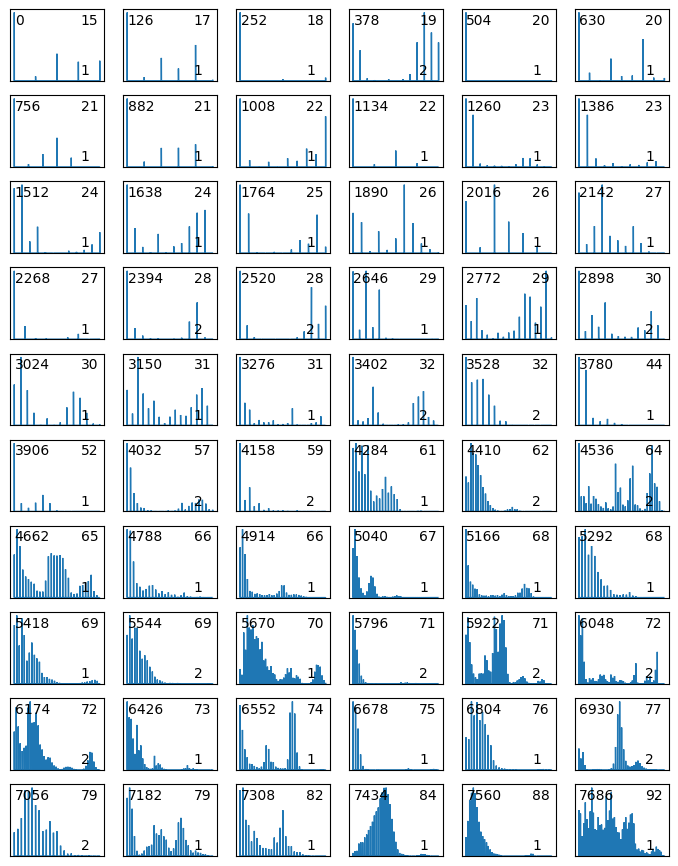

In [71]:
width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

row_stride = int(len(df_subset_numpeaks1or2)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        seq = row.sequence
        hist, bin_edges = get_subopt_hist(seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist, bin_edges)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('subopt_hist.pdf', bbox_inches='tight', pad_inches=0.25)